# CRAB periscope: analytic and deterministic optimization

This is the authoritative, self-contained analysis. Figures and tables are embedded in this executed notebook; no result PNG or CSV files are produced. Fixed dimensions are imported from `DATA`, while reusable calculations live in `SRC/KingCRAB`.

The calculation integrates over the **entire finite EL volume** and the Lens-1 pupil with fixed Gauss–Legendre/azimuthal quadrature. It is deterministic, not Monte Carlo. Results are shown both as absolute isotropic-emission probabilities and as percentages conditional on geometrical capture by Lens 1.

In [1]:
from dataclasses import asdict
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display
from SRC.KingCRAB.analysis import *
from DATA.crab_nexus_geometry import POSITION_BOUNDS_MM
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
g = Geometry()
print('Geometry source: NEXUS KingCRAB.cc transcription in DATA/crab_nexus_geometry.py')
display(pd.DataFrame({'parameter':asdict(g).keys(),'value':asdict(g).values()}))

Geometry source: NEXUS KingCRAB.cc transcription in DATA/crab_nexus_geometry.py


,parameter,value
0,z_l1,1136.9
1,d_m2_l2,185.394026
2,d_m2_ii,239.4
3,lens_diameter,50.8
4,lens_thickness,12.5
5,lens_radius,34.39
6,mirror_diameter,50.8
7,ii_diameter,50.8
8,el_diameter,382.0
9,el_thickness,7.0


## 1. Coordinate system and permitted motion

The EL-to-Mirror-1 segment is global +z. Mirror 1 redirects onto the fixed diagonal toward Mirror 2. Mirror 2 defines the outgoing axis through the 50.8 mm endcap bore. The M1–M2 distance is fixed. Only `z_l1`, `d_m2_l2`, and `d_m2_ii` move; Lens 2 and the II remain exactly collinear with the Mirror-2 outgoing axis.

In [2]:
display(pd.DataFrame(POSITION_BOUNDS_MM,index=['minimum_mm','maximum_mm']).T)
print('M1→M2 fixed Euclidean distance (mm):', np.linalg.norm(M2-M1))
print('Lens 2 collinearity residual:', np.linalg.norm(np.cross(g.l2-M2,UOUT)))
print('II collinearity residual:', np.linalg.norm(np.cross(g.ii-M2,UOUT)))

,minimum_mm,maximum_mm
z_l1,1080.0,1175.0
d_m2_l2,115.0,210.0
d_m2_ii,215.0,255.0


M1→M2 fixed Euclidean distance (mm): 165.11836513241042
Lens 2 collinearity residual: 0.0
II collinearity residual: 0.0


## 2. Full-EL Lens-1 geometrical capture

,method,capture_probability,el_radius_mm,el_gap_thickness_mm,lens_radius_mm,lens1_z_mm
0,on-axis analytic point (not denominator),0.000125,NaN,NaN,NaN,NaN
1,full EL disk + 7 mm gap to full Lens-1 disk (d...,0.000122,191.0,7.0,25.4,1136.9


Full finite-EL Lens-1 capture = 0.012216% of isotropic EL photons


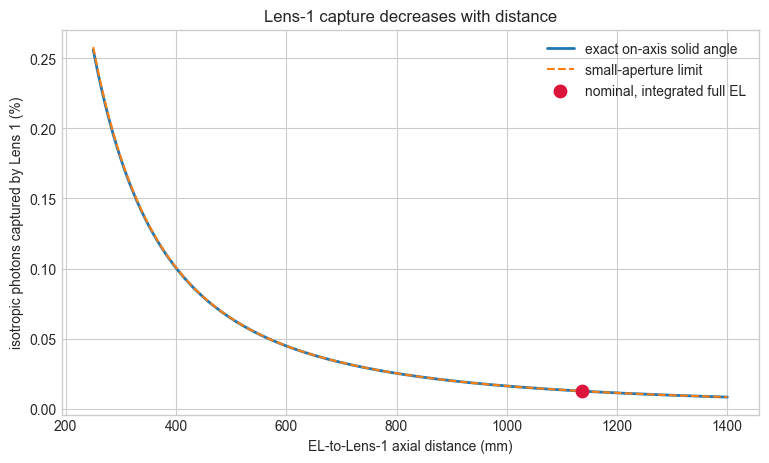

In [3]:
l1check=lens1_capture_crosscheck(g)
display(l1check)
full_el=photon_yield_style_full_el_capture(g)
print(f'Full finite-EL Lens-1 capture = {100*full_el:.6f}% of isotropic EL photons')
z=np.linspace(250,1400,160); ex=np.array([onaxis_collection_exact(v,g.lens_diameter/2) for v in z]); ap=np.array([onaxis_collection_small(v,g.lens_diameter/2) for v in z])
fig,ax=plt.subplots(figsize=(9,5)); ax.plot(z,100*ex,label='exact on-axis solid angle',lw=2); ax.plot(z,100*ap,'--',label='small-aperture limit'); ax.scatter([g.z_l1],[100*full_el],s=80,c='crimson',zorder=4,label='nominal, integrated full EL'); ax.set(xlabel='EL-to-Lens-1 axial distance (mm)',ylabel='isotropic photons captured by Lens 1 (%)',title='Lens-1 capture decreases with distance'); ax.legend(); plt.show()

## 3. Analytic focus, magnification, étendue and aperture checks

In [4]:
display(pd.DataFrame([analytic_checks(g)]).T.rename(columns={0:'value'}))
display(projected_apertures(g))
display(pd.DataFrame([paraxial_system(g)]).T.rename(columns={0:'value'}))

,value
exact,0.000125
small_aperture,0.000125
disk_quadrature,0.000125
relative_small_error,0.000374


,component,diameter_mm,projection_factor,projected_diameter_mm
0,Lens 1,50.8,1.000000,50.800000
1,Mirror 1,50.8,0.707107,35.921024
2,Mirror 2,50.8,0.707107,35.921024
3,Endcap bore,50.8,1.000000,50.800000
4,Lens 2,50.8,1.000000,50.800000
5,II,50.8,1.000000,50.800000


,value
efl_mm,56.281678
bfl_mm,48.522684
focus_from_l2_mm,58.758114
predicted_d_m2_ii_mm,244.15214
magnification,0.009472
ABCD,"[[0.009471826989348127, 5.590944086777023e-14]..."


## 4. Deterministic quadrature verification

In [5]:
qel=disk_quadrature(g.el_diameter/2,12,48); qp=disk_quadrature(g.lens_diameter/2,12,48)
display(pd.DataFrame({'quadrature':['EL disk','Lens-1 pupil'],'nodes':[len(qel),len(qp)],'area_sum_mm2':[qel.area_weight.sum(),qp.area_weight.sum()],'analytic_area_mm2':[np.pi*(g.el_diameter/2)**2,np.pi*(g.lens_diameter/2)**2],'normalized_weight_sum':[qel.normalized_weight.sum(),qp.normalized_weight.sum()]}))

,quadrature,nodes,area_sum_mm2,analytic_area_mm2,normalized_weight_sum
0,EL disk,576,114608.441596,114608.441596,1.0
1,Lens-1 pupil,576,2026.829916,2026.829916,1.0


## 5. Convergence with deterministic numerical error bars

,field_radial_order,field_azimuth_nodes,pupil_radial_order,pupil_azimuth_nodes,runtime_s,valid,reason,objective,weighted_efficiency,geometrical_acceptance,conditional_geometrical_acceptance,worst_field_efficiency,field_cv,coverage,rms_spot_mm,r80_mm,magnification,distortion_mm,n_rays,loss_L1,loss_M1,loss_M2,loss_ENDCAP_BORE,loss_L2,loss_II,lens1_geometrical_capture,geometrical_acceptance_post_L1_percent,weighted_efficiency_post_L1_percent,worst_field_efficiency_post_L1_percent,geometrical_acceptance_successive_change_percent,weighted_efficiency_successive_change_percent,geometrical_acceptance_post_L1_percent_successive_change_percent,weighted_efficiency_post_L1_percent_successive_change_percent,r80_mm_successive_change_percent,distortion_mm_successive_change_percent
0,3,12,4,16,2.710640,True,,0.214492,5.640159e-07,0.000003,0.027546,4.622512e-10,0.723133,1.0,2.191399,2.459782,0.018174,1.758745,34560,0,4615,27267,995,731,0,0.000122,2.059302,0.461696,0.000378,NaN,NaN,NaN,NaN,NaN,NaN
1,4,16,5,20,7.481634,True,,0.351482,6.013656e-07,0.000002,0.028958,1.729672e-09,0.329532,1.0,2.759536,2.774329,0.012577,1.413201,96000,2520,12634,73480,2628,1958,0,0.000122,2.042638,0.492270,0.001416,0.809204,6.622100,0.809204,6.622100,12.787572,19.647222
2,5,20,6,24,17.629609,True,,0.311543,5.688533e-07,0.000003,0.030537,5.669947e-10,0.406577,1.0,2.799055,2.740357,0.005640,1.151279,216000,9080,27953,161620,6391,4360,0,0.000122,2.135887,0.465655,0.000464,4.565154,5.406417,4.565154,5.406417,1.224497,18.533920
3,6,24,7,28,36.188701,True,,0.366569,6.072913e-07,0.000003,0.031718,5.877696e-10,0.424567,1.0,2.526809,2.632401,0.006761,0.732114,423360,18900,54406,315317,12527,8782,0,0.000122,2.148045,0.497120,0.000481,0.569198,6.757117,0.569198,6.757117,3.939510,36.408641
4,7,28,8,32,57.571617,True,,0.391704,6.402798e-07,0.000003,0.032504,2.449351e-10,0.489932,1.0,2.614837,2.727888,0.008361,0.424429,752640,33600,96472,559946,21431,16727,0,0.000122,2.247188,0.524124,0.000201,4.615512,5.432068,4.615512,5.432068,3.627397,42.026895
5,8,32,10,40,116.484167,True,,0.363751,6.110961e-07,0.000003,0.032740,2.211984e-10,0.491066,1.0,2.863789,2.798575,0.007893,0.315883,1536000,73520,195516,1137301,44272,35103,0,0.000122,2.153922,0.500235,0.000181,4.150348,4.557959,4.150348,4.557959,2.591251,25.574559
6,9,36,12,48,212.136960,True,,0.364545,6.135746e-07,0.000003,0.034580,1.526258e-10,0.489819,1.0,2.790490,2.821541,0.006690,0.342835,2799360,148680,355025,2057350,81181,60321,0,0.000122,2.180916,0.502264,0.000125,1.253241,0.405572,1.253241,0.405572,0.820658,8.532138
7,10,40,14,56,354.861666,True,,0.356564,6.087206e-07,0.000003,0.034823,9.856942e-11,0.507055,1.0,2.870211,2.905665,0.007651,0.229164,4704000,251320,596010,3453496,134599,104767,0,0.000122,2.171035,0.498290,0.000081,0.453038,0.791095,0.453038,0.791095,2.981492,33.156313
8,11,44,16,64,571.694775,True,,0.368462,6.127603e-07,0.000003,0.034637,8.654851e-11,0.499564,1.0,2.971578,2.855125,0.007519,0.130053,7434240,401140,941036,5452103,210533,171925,0,0.000122,2.161993,0.501597,0.000071,0.416518,0.663632,0.416518,0.663632,1.739368,43.248654


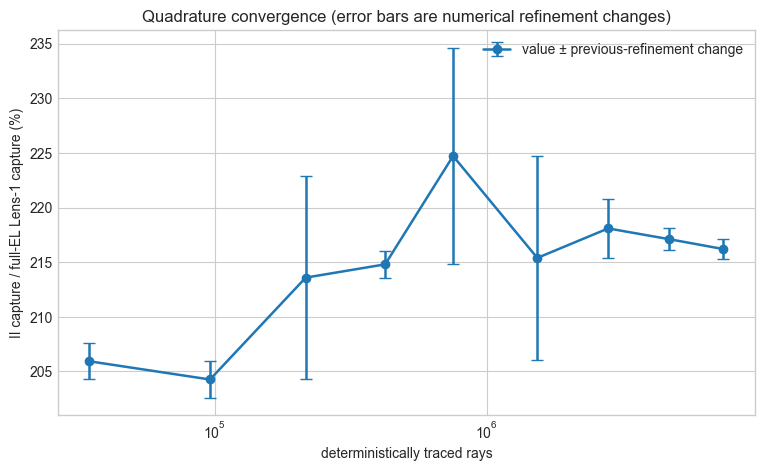

In [6]:
conv=run_dense_convergence(g,orders=((3,4),(4,5),(5,6),(6,7),(7,8),(8,10),(9,12),(10,14),(11,16)))
display(conv)
x=conv.n_rays; y=100*conv.geometrical_acceptance_post_L1_percent
err=np.r_[np.nan, np.abs(np.diff(y))]; err[0]=err[1]
fig,ax=plt.subplots(figsize=(9,5)); ax.errorbar(x,y,yerr=err,fmt='o-',capsize=4,lw=1.8,label='value ± previous-refinement change'); ax.set_xscale('log'); ax.set(xlabel='deterministically traced rays',ylabel='II capture / full-EL Lens-1 capture (%)',title='Quadrature convergence (error bars are numerical refinement changes)'); ax.legend(); plt.show()

## 6. Nominal and paraxially guided focus scan

,exact,small_aperture,disk_quadrature,relative_small_error
0,0.000125,0.000125,0.000125,0.000374


,d_m2_ii,paraxial_prediction,runtime_s,valid,reason,objective,weighted_efficiency,geometrical_acceptance,conditional_geometrical_acceptance,worst_field_efficiency,field_cv,coverage,rms_spot_mm,r80_mm,magnification,distortion_mm,n_rays,loss_L1,loss_M1,loss_M2,loss_ENDCAP_BORE,loss_L2,loss_II,lens1_geometrical_capture,geometrical_acceptance_post_L1_percent,weighted_efficiency_post_L1_percent,worst_field_efficiency_post_L1_percent
0,232.152140,244.15214,7.360124,True,,0.301540,6.013656e-07,0.000002,0.028958,1.729672e-09,0.329532,1.0,2.878783,3.641960,0.012242,1.794111,96000,2520,12634,73480,2628,1958,0,0.000122,2.042638,0.49227,0.001416
1,234.056128,244.15214,7.340356,True,,0.321588,6.013656e-07,0.000002,0.028958,1.729672e-09,0.329532,1.0,2.671583,3.307770,0.012330,1.627095,96000,2520,12634,73480,2628,1958,0,0.000122,2.042638,0.49227,0.001416
2,235.960116,244.15214,7.341784,True,,0.338218,6.013656e-07,0.000002,0.028958,1.729672e-09,0.329532,1.0,2.590517,3.017616,0.012418,1.501505,96000,2520,12634,73480,2628,1958,0,0.000122,2.042638,0.49227,0.001416
3,237.864105,244.15214,7.328528,True,,0.349090,6.013656e-07,0.000002,0.028958,1.729672e-09,0.329532,1.0,2.637043,2.818998,0.012506,1.428310,96000,2520,12634,73480,2628,1958,0,0.000122,2.042638,0.49227,0.001416
4,239.768093,244.15214,7.330206,True,,0.350359,6.013656e-07,0.000002,0.028958,1.729672e-09,0.329532,1.0,2.799360,2.799928,0.012594,1.415662,96000,2520,12634,73480,2628,1958,0,0.000122,2.042638,0.49227,0.001416
5,241.672082,244.15214,7.346601,True,,0.337931,6.013656e-07,0.000002,0.028958,1.729672e-09,0.329532,1.0,3.066759,3.061176,0.012682,1.465129,96000,2520,12634,73480,2628,1958,0,0.000122,2.042638,0.49227,0.001416
6,243.576070,244.15214,7.335710,True,,0.318979,6.013656e-07,0.000002,0.028958,1.729672e-09,0.329532,1.0,3.426109,3.429233,0.012770,1.570854,96000,2520,12634,73480,2628,1958,0,0.000122,2.042638,0.49227,0.001416
7,245.480058,244.15214,7.329570,True,,0.291568,6.013656e-07,0.000002,0.028958,1.729672e-09,0.329532,1.0,3.853418,3.962870,0.012858,1.722508,96000,2520,12634,73480,2628,1958,0,0.000122,2.042638,0.49227,0.001416
8,247.384047,244.15214,7.340110,True,,0.256044,6.013656e-07,0.000002,0.028958,1.729672e-09,0.329532,1.0,4.327392,4.664285,0.012946,1.909179,96000,2520,12634,73480,2628,1958,0,0.000122,2.042638,0.49227,0.001416
9,249.288035,244.15214,7.335220,True,,-4.782243,6.013656e-07,0.000002,0.028958,1.729672e-09,0.329532,1.0,4.833516,5.408991,0.013035,2.121643,96000,2520,12634,73480,2628,1958,0,0.000122,2.042638,0.49227,0.001416


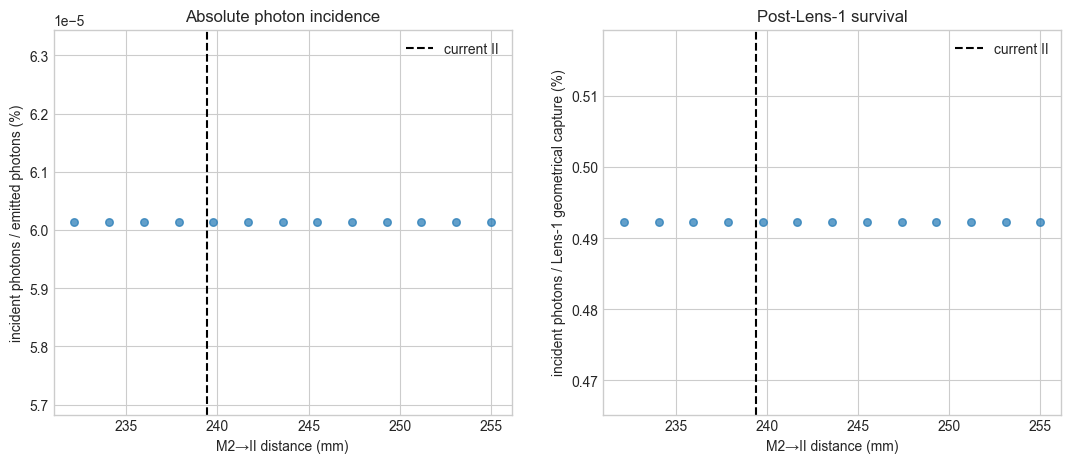

In [7]:
checks,scan=run_hybrid_demo(); display(checks); display(scan.sort_values('weighted_efficiency',ascending=False).head(12))
fig,axs=plt.subplots(1,2,figsize=(13,5));
axs[0].scatter(scan.d_m2_ii,100*scan.weighted_efficiency,s=30,alpha=.7); axs[0].axvline(g.d_m2_ii,color='k',ls='--',label='current II'); axs[0].set(xlabel='M2→II distance (mm)',ylabel='incident photons / emitted photons (%)',title='Absolute photon incidence'); axs[0].legend()
axs[1].scatter(scan.d_m2_ii,scan.weighted_efficiency_post_L1_percent,s=30,alpha=.7); axs[1].axvline(g.d_m2_ii,color='k',ls='--',label='current II'); axs[1].set(xlabel='M2→II distance (mm)',ylabel='incident photons / Lens-1 geometrical capture (%)',title='Post-Lens-1 survival'); axs[1].legend(); plt.show()

## 7. Argon and xenon pressure dependence

,gas,pressure_bar,selection,emission_centroid_nm,gas_refractive_index,paraxial_d_m2_ii,runtime_s,z_l1,d_m2_l2,d_m2_ii,valid,reason,objective,weighted_efficiency,geometrical_acceptance,conditional_geometrical_acceptance,worst_field_efficiency,field_cv,coverage,rms_spot_mm,r80_mm,magnification,distortion_mm,n_rays,loss_L1,loss_M1,loss_M2,loss_ENDCAP_BORE,loss_L2,loss_II,lens1_geometrical_capture,geometrical_acceptance_post_L1_percent,weighted_efficiency_post_L1_percent,worst_field_efficiency_post_L1_percent
0,argon,1.0,nominal,128.000000,1.000444,214.278685,19.184196,1136.9,185.394026,239.400000,True,,-31.197922,0.000000e+00,5.263398e-07,0.008231,0.000000e+00,99.000000,0.0,11.118310,15.110931,0.021365,8.587112,294000,39600,139188,105140,3538,3182,932,0.000122,0.430854,0.000000,0.000000
1,argon,1.0,paraxial_guided,128.000000,1.000444,214.278685,19.487611,1136.9,185.394026,215.000000,True,,-30.553148,0.000000e+00,7.235059e-07,0.010993,0.000000e+00,99.000000,0.0,4.876823,5.015953,0.020211,2.562743,294000,39600,139188,105140,3538,3182,120,0.000122,0.592252,0.000000,0.000000
2,argon,3.0,nominal,128.000000,1.001332,214.339114,19.105302,1136.9,185.394026,239.400000,True,,-31.192872,0.000000e+00,5.300771e-07,0.008299,0.000000e+00,99.000000,0.0,11.105004,15.139986,0.024042,8.431826,294000,39520,138991,105397,3541,3183,928,0.000122,0.433914,0.000000,0.000000
3,argon,3.0,paraxial_guided,128.000000,1.001332,214.339114,19.529499,1136.9,185.394026,215.000000,True,,-30.552656,0.000000e+00,7.275038e-07,0.011048,0.000000e+00,99.000000,0.0,4.852054,5.013527,0.020242,2.552871,294000,39520,138991,105397,3541,3183,120,0.000122,0.595525,0.000000,0.000000
4,argon,5.0,nominal,128.000000,1.002223,214.399748,19.335960,1136.9,185.394026,239.400000,True,,-31.184816,0.000000e+00,5.331454e-07,0.008327,0.000000e+00,99.000000,0.0,11.077741,14.984926,0.023967,8.385482,294000,39416,138780,105683,3555,3190,928,0.000122,0.436425,0.000000,0.000000
5,argon,5.0,paraxial_guided,128.000000,1.002223,214.399748,19.139293,1136.9,185.394026,215.000000,True,,-30.552214,0.000000e+00,7.308932e-07,0.011102,0.000000e+00,99.000000,0.0,4.830825,5.007421,0.020294,2.547928,294000,39416,138780,105683,3555,3190,112,0.000122,0.598299,0.000000,0.000000
6,argon,7.5,nominal,128.000000,1.003340,214.476092,19.050688,1136.9,185.394026,239.400000,True,,-31.178875,0.000000e+00,5.355921e-07,0.008408,0.000000e+00,99.000000,0.0,11.177757,14.874437,0.023508,8.347435,294000,39240,138553,106050,3566,3199,920,0.000122,0.438428,0.000000,0.000000
7,argon,7.5,paraxial_guided,128.000000,1.003340,214.476092,19.227150,1136.9,185.394026,215.000000,True,,-30.551992,0.000000e+00,7.318140e-07,0.011129,0.000000e+00,99.000000,0.0,4.786775,4.958829,0.021045,2.590974,294000,39240,138553,106050,3566,3199,120,0.000122,0.599053,0.000000,0.000000
8,argon,10.0,nominal,128.000000,1.004458,214.552648,19.169241,1136.9,185.394026,239.400000,True,,-31.170606,0.000000e+00,5.379654e-07,0.008463,0.000000e+00,99.000000,0.0,11.053258,14.779395,0.021303,8.235746,294000,39056,138375,106383,3561,3201,936,0.000122,0.440371,0.000000,0.000000
9,argon,10.0,paraxial_guided,128.000000,1.004458,214.552648,19.877460,1136.9,185.394026,215.000000,True,,-30.546266,0.000000e+00,7.311480e-07,0.011156,0.000000e+00,99.000000,0.0,4.697631,4.862942,0.021296,2.543697,294000,39056,138375,106383,3561,3201,144,0.000122,0.598508,0.000000,0.000000


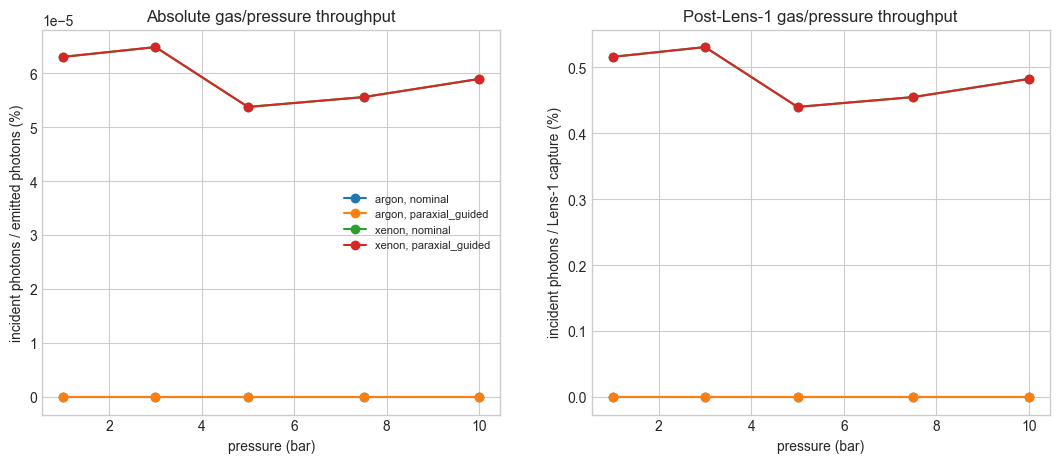

In [8]:
gp=run_gas_pressure_hybrid(nfield=5,nap=7); display(gp)
fig,axs=plt.subplots(1,2,figsize=(13,5));
for (gas,sel),q in gp.groupby(['gas','selection']):
    axs[0].plot(q.pressure_bar,100*q.weighted_efficiency,'-o',label=f'{gas}, {sel}')
    axs[1].plot(q.pressure_bar,q.weighted_efficiency_post_L1_percent,'-o',label=f'{gas}, {sel}')
axs[0].set(xlabel='pressure (bar)',ylabel='incident photons / emitted photons (%)',title='Absolute gas/pressure throughput'); axs[1].set(xlabel='pressure (bar)',ylabel='incident photons / Lens-1 capture (%)',title='Post-Lens-1 gas/pressure throughput')
for ax in axs: ax.legend(fontsize=8); plt.show()

## 8. Three permitted distances: maxima and current-position boxes

In [ ]:
profiles,recommended=throughput_profiles(g,nfield=4,nap=6,npoints=15); display(recommended)
labels={'z_l1':'Lens 1 global z (mm)','d_m2_l2':'M2→Lens 2 distance (mm)','d_m2_ii':'M2→II distance (mm)'}
current={'z_l1':g.z_l1,'d_m2_l2':g.d_m2_l2,'d_m2_ii':g.d_m2_ii}
for metric,ylabel,title in [('weighted_efficiency','incident photons / emitted photons','Absolute throughput'),('weighted_efficiency_post_L1_percent','incident photons / Lens-1 capture (%)','Post-Lens-1 throughput')]:
    fig,axs=plt.subplots(1,3,figsize=(16,4.8))
    for ax,(var,q) in zip(axs,profiles.groupby('variable',sort=False)):
        q=q.sort_values('position_mm'); info=recommended.query('variable == @var').iloc[0]
        ax.plot(q.position_mm,q[metric],'-o',ms=4)
        ax.axvspan(current[var]-.75,current[var]+.75,color='tab:red',alpha=.22,label=f'current {current[var]:.1f} mm')
        if info.throughput_sensitive:
            ax.axvline(info.recommended_mm,color='tab:green',lw=2,label=f'throughput maximum {info.recommended_mm:.1f} mm')
        else:
            ax.text(.04,.94,'Photon count is insensitive here',transform=ax.transAxes,va='top',bbox=dict(facecolor='white',edgecolor='0.5',alpha=.9))
        if np.isfinite(info.best_focus_mm):
            ax.axvline(info.best_focus_mm,color='tab:blue',ls='--',lw=1.8,label=f'best sampled focus {info.best_focus_mm:.1f} mm')
        ax.set(xlabel=labels[var],ylabel=ylabel,title=f'{var}: throughput span {info.relative_throughput_span_percent:.2f}%'); ax.legend(fontsize=7)
    fig.suptitle(title+' versus allowed degrees of freedom'); fig.tight_layout(); plt.show()

## 9. Interpretation and readiness

Absolute collection must fall as Lens 1 moves farther from the EL because its subtended solid angle decreases. A downstream conditional metric can nevertheless improve if the narrower accepted angular bundle suffers less clipping at Mirror 2 and the endcap bore. Both quantities are therefore retained and never conflated.

Across the allowed II range, photon incidence is effectively flat: moving the II is not a throughput remedy. The current 239.4 mm II position is therefore retained when discussing photon count. Any II translation must instead be justified by the R80/focus curve and tolerance margin.

The notebook reports deterministic quadrature-refinement changes rather than statistical Monte Carlo errors. Hardware placement is justified only if the final two refinements are stable at the declared 1–2% scale and the optimum is not an arbitrary active bound. Optical probabilities remain distinct from II photoelectron probability unless an authoritative QE spectrum is supplied.